In [1]:
# Cell 1: install everything we need
# Pinning numpy/pandas versions here because otherwise Colab throws an
# ImportError when scanpy tries to update them mid-session (learned this
# the hard way). If you just ran this cell, restart the runtime before
# running the next one.
!pip install -q scanpy "numpy<2.1" "pandas<2.3"

In [2]:
# Cell 2: imports
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importlib.metadata import version

sc.settings.verbosity = 1
sc.set_figure_params(dpi=80, facecolor="white")

print(f"Scanpy version: {version('scanpy')}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Scanpy version: 1.12
Numpy version: 2.0.2
Pandas version: 2.2.2


In [3]:
# Cell 3: load the dataset
# This comes pre-filtered by 10x (only "real" cell barcodes, no empty droplets),
# but that doesn't mean it's ready to use yet - still need to check quality.
adata = sc.datasets.pbmc3k()

print(adata)
print(f"Cells: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")
print(f"X matrix type: {type(adata.X)}")

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
Cells: 2700
Genes: 32738
X matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [4]:
# Cell 4: mitochondrial genes + QC metrics
# In humans mitochondrial genes start with 'MT-'. When a cell is dying/stressed,
# it tends to lose cytoplasmic RNA but keep mitochondrial RNA, so a high
# percentage of mt genes is basically a red flag for a bad cell.
adata.var['mt'] = adata.var_names.str.startswith('MT-')
print(f"Mitochondrial genes found: {adata.var['mt'].sum()}")

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())

Mitochondrial genes found: 13
       n_genes_by_counts  total_counts  pct_counts_mt
count        2700.000000   2700.000000    2700.000000
mean          846.994074   2366.900391       2.215132
std           282.104964   1094.261963       1.165438
min           212.000000    548.000000       0.000000
25%           690.000000   1757.750000       1.536238
50%           817.000000   2197.000000       2.029639
75%           953.250000   2763.000000       2.640218
max          3422.000000  15844.000000      22.569027


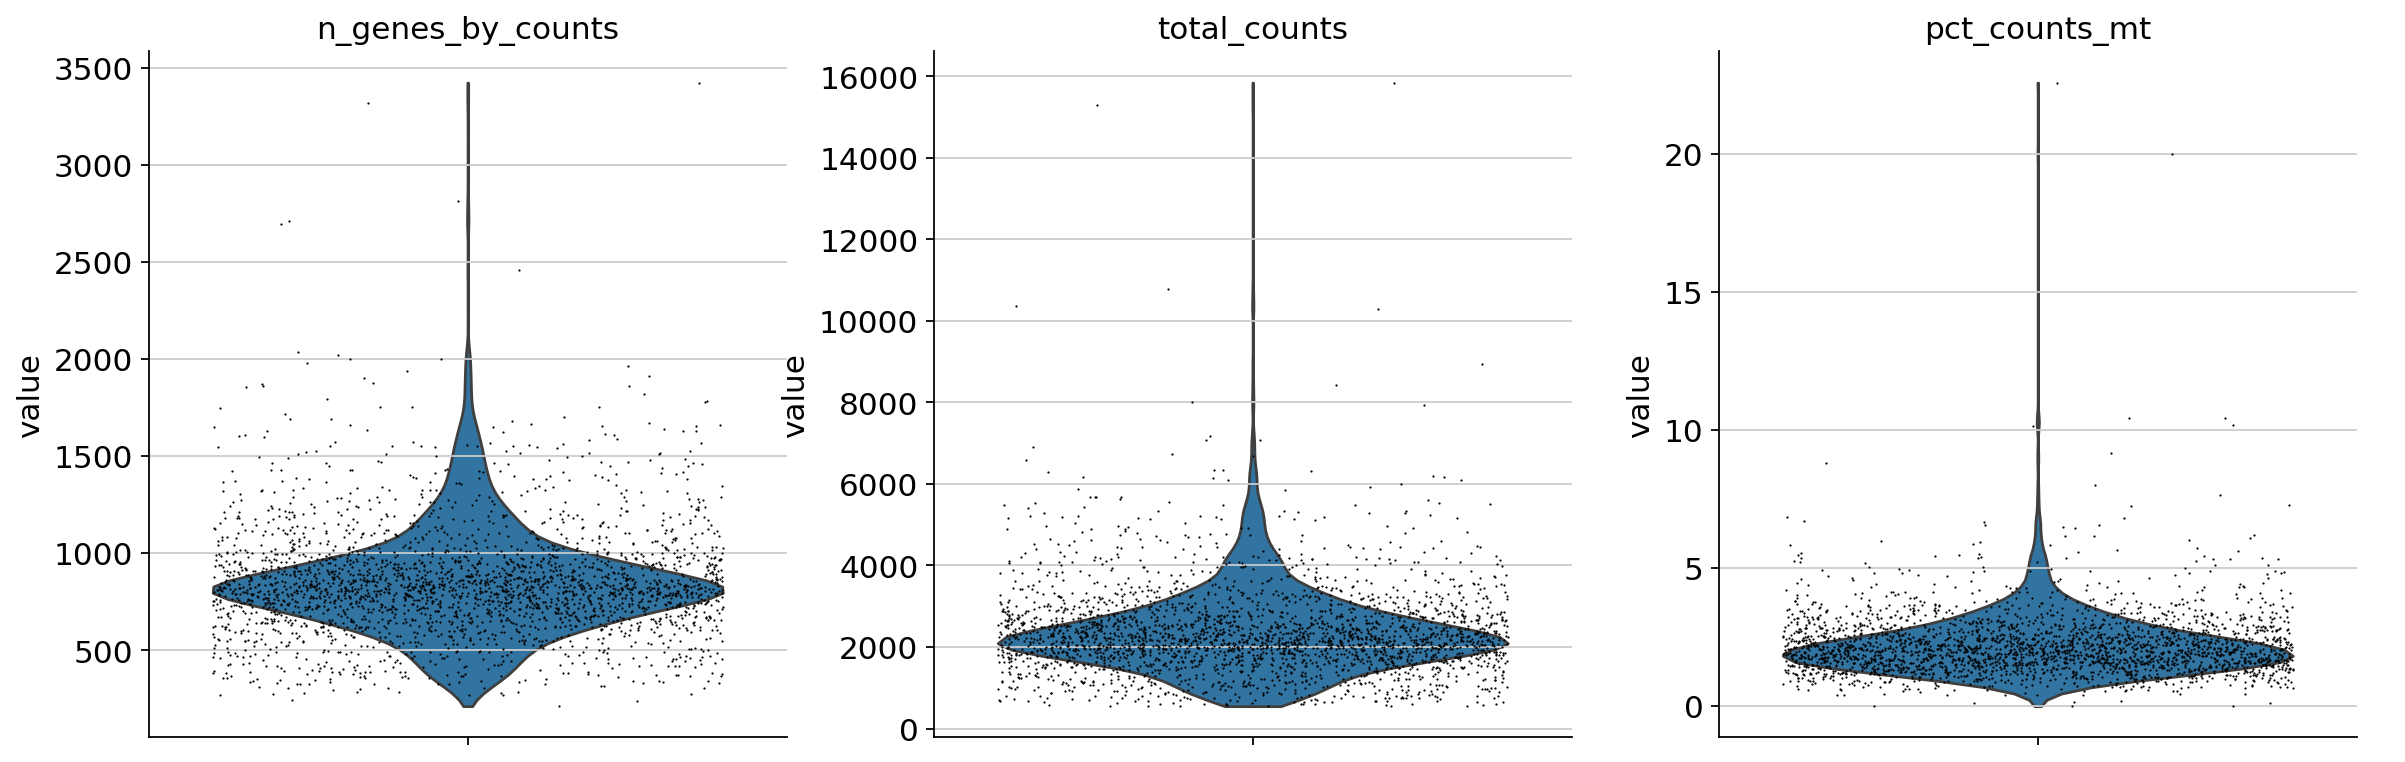

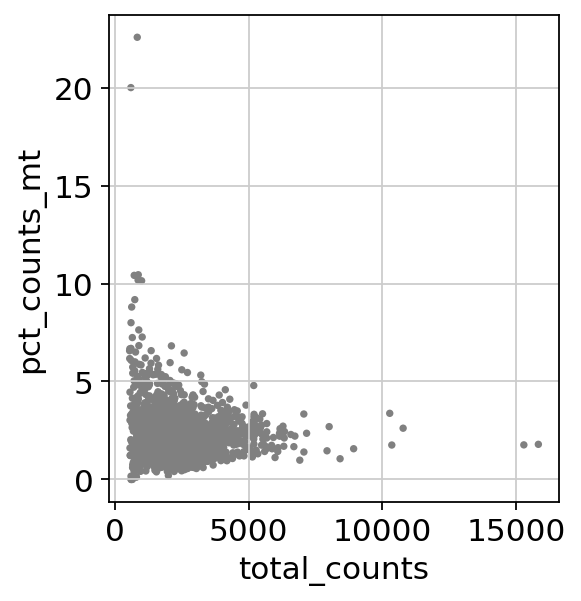

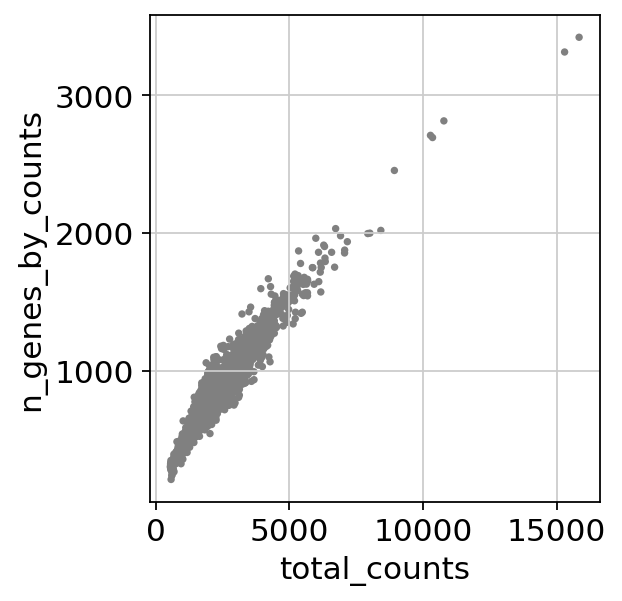

In [5]:
# Cell 5: plot the QC metrics
# Looking at the actual distribution before picking a cutoff, instead of just
# copying a number from a tutorial.
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")


In [6]:
# Cell 6: filter out bad cells
# Cutoffs based on the plots above: cells with too many genes are probably
# doublets (two cells captured together), and cells with >5% mt reads are
# probably dying.
print(f"Cells before filtering: {adata.n_obs}")
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()
print(f"Cells after filtering: {adata.n_obs}")

Cells before filtering: 2700
Cells after filtering: 2638


In [7]:
# Cell 7: filter out genes that barely show up anywhere
# If a gene is only detected in 1-2 cells out of thousands, there's not
# enough signal there to trust it for anything downstream.
print(f"Genes before filtering: {adata.n_vars}")
sc.pp.filter_genes(adata, min_cells=3)
print(f"Genes after filtering: {adata.n_vars}")

Genes before filtering: 32738
Genes after filtering: 13656


In [8]:
# Cell 8: normalize + log transform
# Different cells got different amounts of sequencing "luck" (total counts),
# so we rescale everything to the same total (10k) to make cells comparable.
# log1p just makes the values easier to work with and avoids issues with zeros.
adata.raw = adata  # keep a copy of this for later (marker gene plots need it)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print(f"Max value after log1p: {adata.X.max():.2f}")

Max value after log1p: 7.47


Highly variable genes: 2000


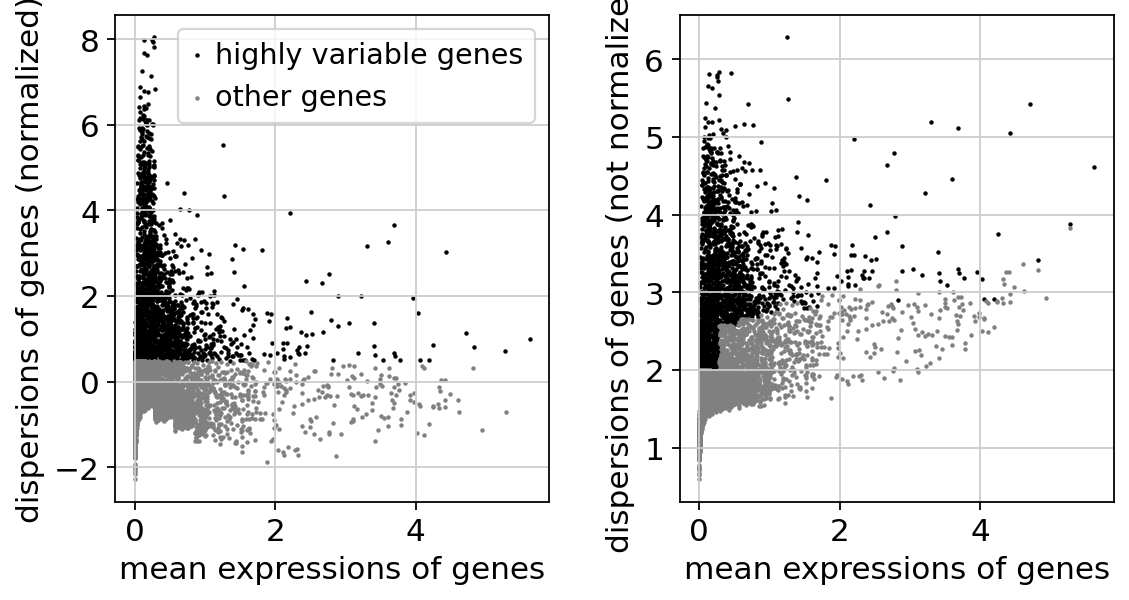

In [9]:
# Cell 9: find the highly variable genes
# Most of the ~13k genes left don't really help tell cell types apart.
# This keeps the top 2000 genes that vary the most (relative to their own
# expression level), which is what we actually cluster on later.
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    n_top_genes=2000,
)
print(f"Highly variable genes: {adata.var.highly_variable.sum()}")
sc.pl.highly_variable_genes(adata)

/usr/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


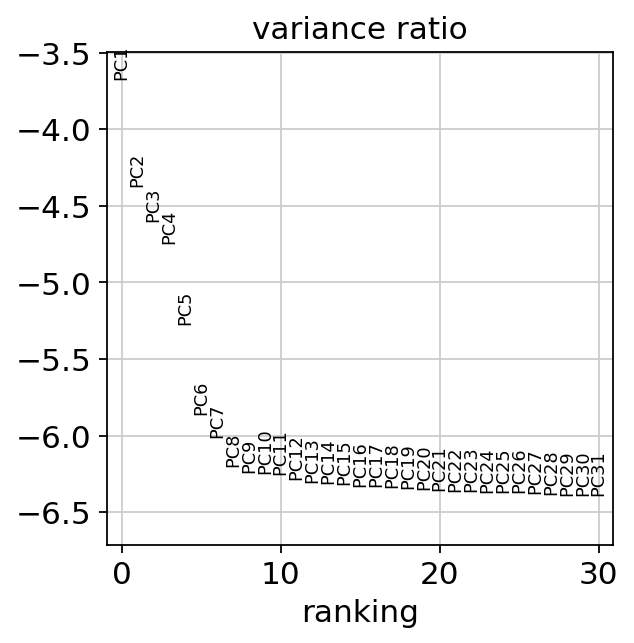

Shape after keeping only HVGs: (2638, 2000)


In [10]:
# Cell 10: PCA
# Scaling first so genes with naturally bigger numbers don't dominate PCA
# just because of their scale, not because they're biologically interesting.
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)
print(f"Shape after keeping only HVGs: {adata.shape}")

In [11]:
# Cell 11: neighbors graph + Leiden clustering
# Using the first 10 PCs (that's roughly where the variance plot flattens out).
!pip install -q python-igraph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)
sc.tl.leiden(adata, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)

print(f"Clusters found: {adata.obs['leiden'].nunique()}")
print(adata.obs['leiden'].value_counts())

Clusters found: 9
leiden
0    755
5    430
3    380
2    344
1    329
4    211
6    142
7     35
8     12
Name: count, dtype: int64


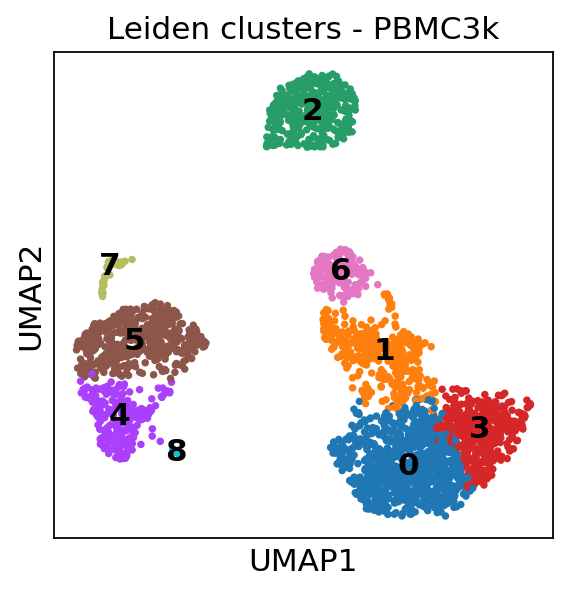

In [12]:
# Cell 12: UMAP
# This is just for visualizing the clusters we already found above - it doesn't
# decide anything on its own, just projects the same neighbor graph into 2D.
sc.tl.umap(adata)
sc.pl.umap(adata, color='leiden', legend_loc='on data', title='Leiden clusters - PBMC3k')


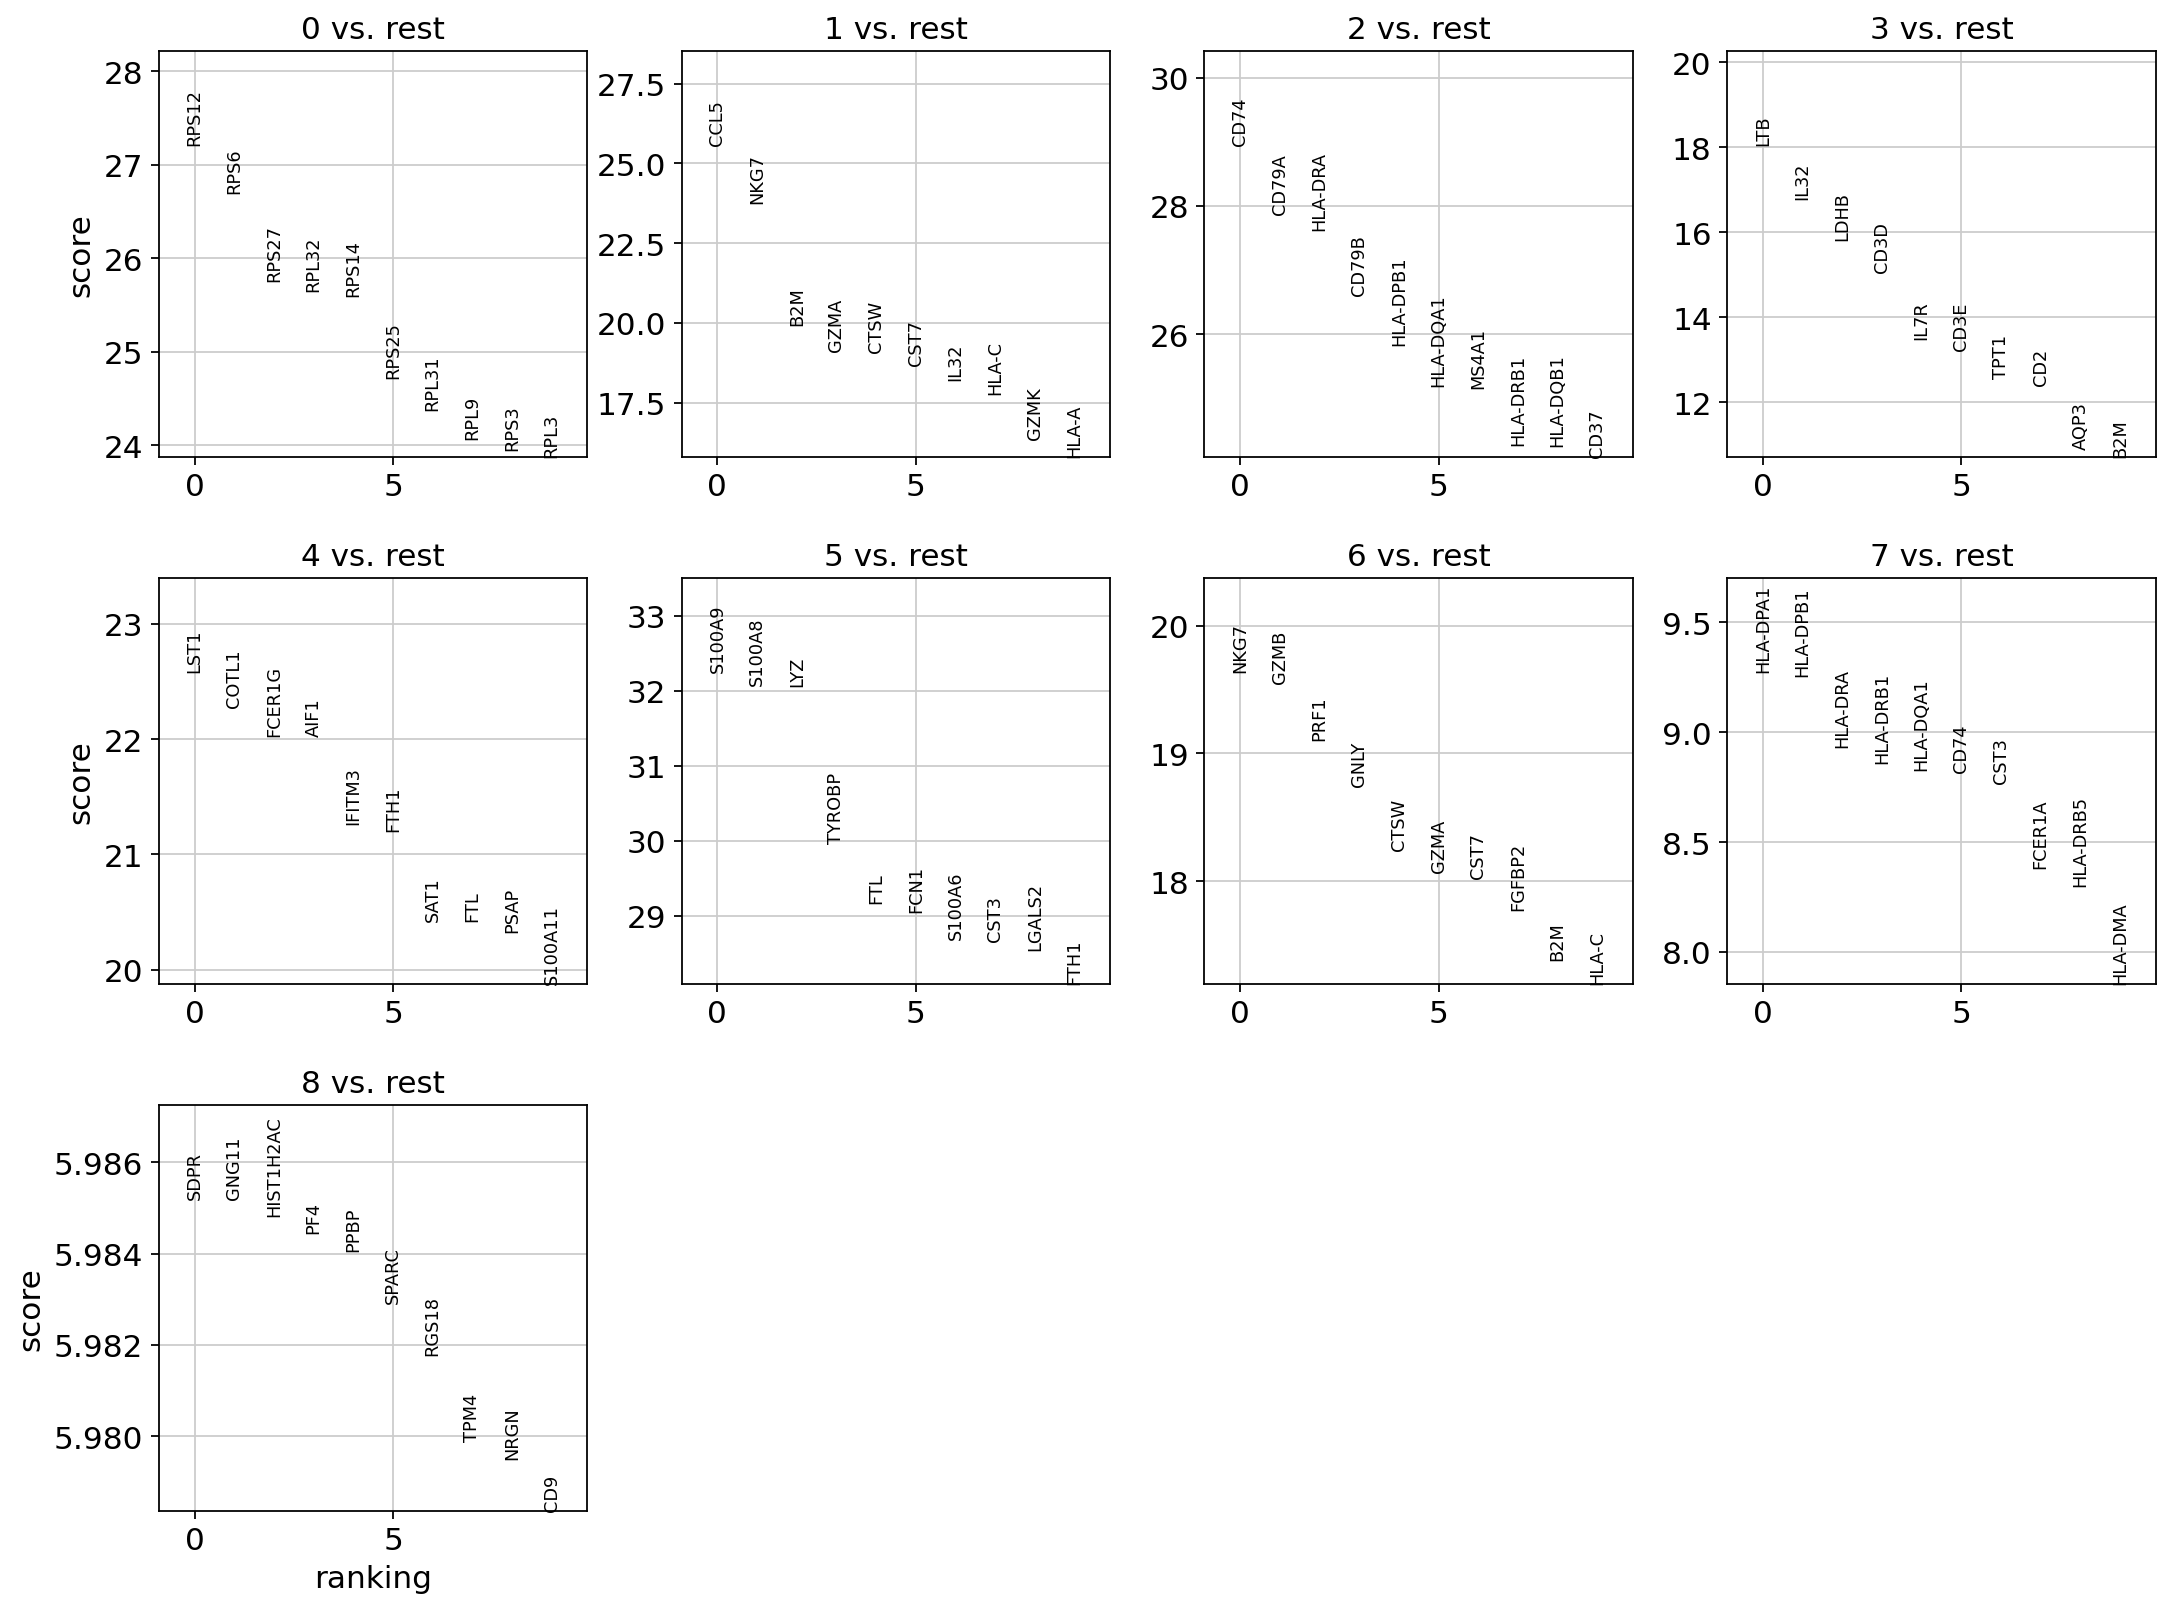

       0     1         2     3       4       5     6         7          8
0  RPS12  CCL5      CD74   LTB    LST1  S100A9  NKG7  HLA-DPA1       SDPR
1   RPS6  NKG7     CD79A  IL32   COTL1  S100A8  GZMB  HLA-DPB1      GNG11
2  RPS27   B2M   HLA-DRA  LDHB  FCER1G     LYZ  PRF1   HLA-DRA  HIST1H2AC
3  RPL32  GZMA     CD79B  CD3D    AIF1  TYROBP  GNLY  HLA-DRB1        PF4
4  RPS14  CTSW  HLA-DPB1  IL7R  IFITM3     FTL  CTSW  HLA-DQA1       PPBP


In [13]:
# Cell 13: find marker genes for each cluster
# For each cluster, comparing it against all other cells combined (not
# cluster-vs-cluster), which matches how marker databases like PanglaoDB
# usually define cell type markers.
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

top_markers = pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(5)
print(top_markers)

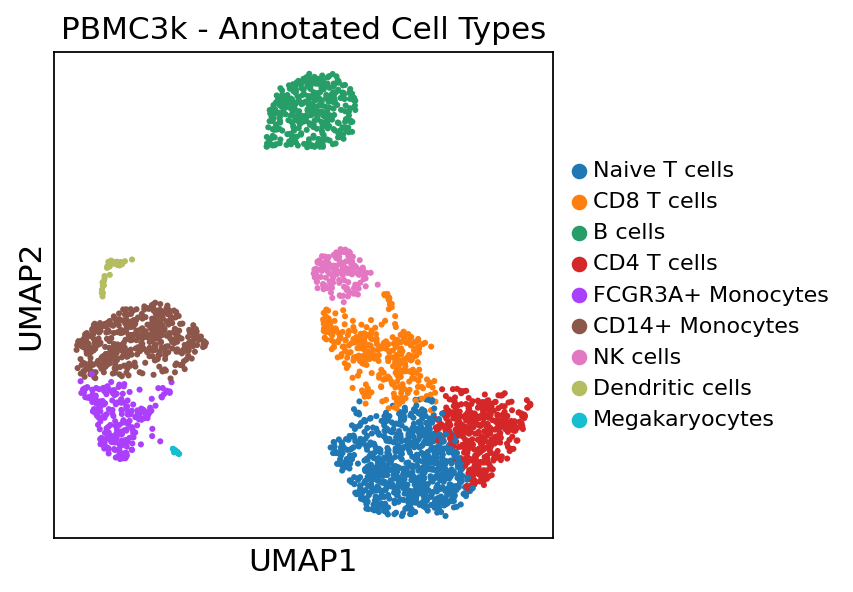

In [15]:
# Cell 14: name the clusters based on their markers
cluster_to_celltype = {
    '0': 'Naive T cells',
    '1': 'CD8 T cells',
    '2': 'B cells',
    '3': 'CD4 T cells',
    '4': 'FCGR3A+ Monocytes',
    '5': 'CD14+ Monocytes',
    '6': 'NK cells',
    '7': 'Dendritic cells',
    '8': 'Megakaryocytes',
}
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype)

sc.pl.umap(
    adata,
    color='cell_type',
    legend_loc='right margin',
    legend_fontsize=10,
    title='PBMC3k - Annotated Cell Types',
    size=30,
)